# Notebook 3 — Data Augmentation & Dataset Balancing
### Diabetic Retinopathy Stage Detection — Computer Vision Coursework
**Rubric target: Criterion 3 (10 marks) — "Effective augmentation techniques used (rotation, flipping, zooming, brightness adjustments, etc.) with strong justification; class imbalance handled appropriately."**

This notebook is the third in a 6-notebook chained pipeline. It loads the preprocessed images and splits produced by Notebook 2, applies a justified augmentation pipeline to the **training split only**, and addresses the 9.35:1 class imbalance identified in Notebook 1 using a **moderate, justified balancing strategy**. Outputs are saved so Notebook 4 (CNN Architecture & Transfer Learning) can load them directly.

---

## Decisions taken in this notebook (with justification)

Three open decisions were left for this notebook. Rather than leaving them unresolved, sensible defaults were chosen and justified below, so the notebook can run end-to-end. Each can be revisited if needed.

**1. Augmentation library: Albumentations** (over Keras `ImageDataGenerator` / `tf.keras` preprocessing layers).
Justification: Albumentations is built on OpenCV, the same library already used throughout Notebook 2's preprocessing pipeline, so there is no format/backend mismatch. It offers fine-grained, independently-controllable parameters for each transform (needed here because rotation, flip and brightness each require a *different*, fundus-specific justification below, not a single generic "data augmentation" block), and it is framework-agnostic — it produces plain NumPy arrays that will work with whichever framework (TensorFlow/Keras or PyTorch) Notebook 4 ultimately uses for transfer learning, so this choice does not lock in a later decision prematurely.

**2. Class-balancing strategy: combination — (c) moderate oversampling here + class weights deferred to Notebook 4.**
Justification: Rubric Criterion 3 explicitly requires imbalance to be "handled appropriately" *in this notebook*, so doing nothing here (option b alone) would not satisfy the criterion. However, fully balancing all classes to equality (option a alone) would mean upsampling Severe (193 real source images) by ~9.35x, i.e. the vast majority of "Severe" training images the model ever sees would be near-duplicates of a very small number of source photographs — a well-documented overfitting risk for the minority class. The combination lets augmentation do a moderate, defensible share of the balancing work, while class weights (computed here, applied in Notebook 4) absorb the remainder without further duplicating source images.

**3. Balancing aggressiveness: moderate partial rebalance, oversampling multiplier capped at 4x per class.**
Justification: capping the oversampling multiplier means no class is expanded past 4 synthetic-augmented copies for every 1 real source image, which keeps a visible floor of image diversity under every class while still meaningfully narrowing the 9.35:1 gap. The residual imbalance after capping is then fully accounted for via the class weights computed at the end of this notebook (Cell 13), so no part of the original imbalance is left unaddressed — it is handled by augmentation *and* weighting together, not by augmentation alone.

**Locked decisions carried over from Notebooks 1–2 (not re-litigated here):** APTOS 2019 dataset, nested Kaggle mount layout, stratified 70/15/15 split (seed=42: train 2,562 / val 550 / test 550), 5-step Notebook 2 preprocessing pipeline already applied (crop → resize 224×224 → CLAHE → Ben Graham → normalize to [0,1]).


In [1]:
# [CELL 1] Import all libraries required for this notebook and confirm their versions.
# Doing this first (rather than importing lazily throughout the notebook) makes the
# notebook's dependency footprint explicit and reproducible for anyone re-running it later.

import os                          # filesystem search for locating Kaggle input mounts
import sys                         # for printing the Python interpreter version
import glob                        # pattern-based file discovery as a secondary search method
import pickle                      # loading/saving the pipeline config and augmentation config
import random                      # setting the non-NumPy random seed for full reproducibility
import shutil                      # copying unaugmented validation/test images into the working tree
from pathlib import Path           # convenient, OS-independent path handling throughout

import numpy as np                 # numerical array operations on image pixel data
import pandas as pd                # loading/joining split CSVs and building the augmentation manifest
import cv2                         # image I/O and any manual pixel-level operations
import matplotlib.pyplot as plt    # visual evidence: before/after grids and class-distribution bar charts
import albumentations as albumentations_library  # the augmentation library chosen for this notebook (see justification above)

training_random_seed = 42  # fixed seed, matching Notebooks 1 and 2, so this notebook's outputs are reproducible

print("[CELL 1] Python version:", sys.version.split()[0])
print("[CELL 1] NumPy version:", np.__version__)
print("[CELL 1] Pandas version:", pd.__version__)
print("[CELL 1] OpenCV version:", cv2.__version__)
print("[CELL 1] Albumentations version:", albumentations_library.__version__)
print(f"[CELL 1] Fixed random seed set for this notebook: {training_random_seed}")


[CELL 1] Python version: 3.12.13
[CELL 1] NumPy version: 2.0.2
[CELL 1] Pandas version: 2.3.3
[CELL 1] OpenCV version: 4.13.0
[CELL 1] Albumentations version: 2.0.8
[CELL 1] Fixed random seed set for this notebook: 42


In [2]:
# [CELL 2] Seed every source of randomness used anywhere in this notebook.
# Augmentation is inherently random (random rotation angle, random brightness shift, etc.),
# so without fixing every RNG the exact augmented images produced would differ on every re-run,
# which would break reproducibility for anyone grading or re-running this notebook.

random.seed(training_random_seed)       # Python's built-in random module (used by some helper shuffles below)
np.random.seed(training_random_seed)    # NumPy's global RNG (used by Albumentations internally)

print(f"[CELL 2] Random seeds fixed for Python `random` and NumPy at seed={training_random_seed}")


[CELL 2] Random seeds fixed for Python `random` and NumPy at seed=42


In [3]:
# [CELL 3] Locate Notebook 2's saved outputs (preprocessed images + split CSVs + pipeline config)
# anywhere under /kaggle/input, rather than assuming a single fixed path.
#
# WHY a search instead of a hardcoded path: Notebooks 1 and 2 both hit the same issue — their own
# previous notebook's output was not attached as a Kaggle input, so both silently fell back to
# regenerating their inputs from scratch. That fallback was functionally correct but wastes GPU/CPU
# time and re-introduces a (harmless but avoidable) point where things could drift. This cell makes
# the "not attached" case loud and explicit, and reports exactly what to attach next time.

def search_kaggle_inputs_for_file(target_filename, search_root="/kaggle/input"):
    """Walk every directory under search_root looking for an exact filename match.
    Returns a list of full paths (usually 0 or 1 matches, but a list handles duplicates safely)."""
    matches_found = []
    if os.path.isdir(search_root):
        for current_directory, _subdirectories, files_in_current_directory in os.walk(search_root):
            if target_filename in files_in_current_directory:
                matches_found.append(os.path.join(current_directory, target_filename))
    return matches_found


def search_kaggle_inputs_for_directory(target_directory_name, search_root="/kaggle/input"):
    """Walk every directory under search_root looking for an exact directory-name match."""
    matches_found = []
    if os.path.isdir(search_root):
        for current_directory, subdirectories, _files_in_current_directory in os.walk(search_root):
            for subdirectory_name in subdirectories:
                if subdirectory_name == target_directory_name:
                    matches_found.append(os.path.join(current_directory, subdirectory_name))
    return matches_found


# Search for the three artefacts Notebook 2 is supposed to have saved.
pipeline_config_matches = search_kaggle_inputs_for_file("preprocessing_pipeline_config.pkl")
preprocessed_images_directory_matches = search_kaggle_inputs_for_directory("preprocessed_images")
train_split_csv_matches = search_kaggle_inputs_for_file("train_split.csv")

notebook_2_outputs_found = bool(pipeline_config_matches and preprocessed_images_directory_matches and train_split_csv_matches)

if notebook_2_outputs_found:
    pipeline_config_path = pipeline_config_matches[0]
    preprocessed_images_root = preprocessed_images_directory_matches[0]
    # The split CSVs are expected alongside train_split.csv in the same directory.
    split_csv_directory = os.path.dirname(train_split_csv_matches[0])
    print("[CELL 3] Notebook 2 outputs FOUND as attached Kaggle inputs.")
    print(f"[CELL 3] Pipeline config: {pipeline_config_path}")
    print(f"[CELL 3] Preprocessed images root: {preprocessed_images_root}")
    print(f"[CELL 3] Split CSV directory: {split_csv_directory}")
else:
    print("[CELL 3] Notebook 2 outputs NOT found under /kaggle/input.")
    print("[CELL 3] FALLBACK REQUIRED: this notebook will regenerate the split (seed=42) and")
    print("[CELL 3] re-run Notebook 2's preprocessing pipeline in the next three cells.")
    print("[CELL 3] ACTION FOR NEXT TIME: attach Notebook 2's Kaggle Notebook Output as an input")
    print("[CELL 3] to this notebook (Add Data -> Notebook Output -> select Notebook 2) so this")
    print("[CELL 3] fallback is not needed on the next run.")


[CELL 3] Notebook 2 outputs FOUND as attached Kaggle inputs.
[CELL 3] Pipeline config: /kaggle/input/notebooks/oshadhaksamarasinghe/notebook-2-data-preprocessing/preprocessing_pipeline_config.pkl
[CELL 3] Preprocessed images root: /kaggle/input/notebooks/oshadhaksamarasinghe/notebook-2-data-preprocessing/preprocessed_images
[CELL 3] Split CSV directory: /kaggle/input/notebooks/oshadhaksamarasinghe/notebook-2-data-preprocessing


In [4]:
# [CELL 4] FALLBACK STEP 1: if Notebook 2's outputs were not found, locate the raw APTOS 2019
# dataset and regenerate the identical stratified 70/15/15 split using the same seed and logic
# as Notebooks 1 and 2. This produces byte-for-byte identical split membership because the seed,
# the source CSV and the stratification method are all unchanged from before.

from sklearn.model_selection import train_test_split  # only needed inside this fallback path

if not notebook_2_outputs_found:

    # Locate the raw dataset the same way Notebooks 1 and 2 did: search rather than hardcode,
    # since this Kaggle account uses a nested mount layout.
    raw_train_csv_matches = search_kaggle_inputs_for_file("train.csv")
    # Prefer a match whose path also contains "aptos2019-blindness-detection" if multiple train.csv
    # files exist anywhere under /kaggle/input (e.g. the Gaussian-filtered reference dataset also
    # ships its own train.csv, per Notebook 1's findings).
    raw_train_csv_matches = [p for p in raw_train_csv_matches if "aptos2019-blindness-detection" in p] or raw_train_csv_matches
    if not raw_train_csv_matches:
        raise FileNotFoundError(
            "[CELL 4] Could not locate the raw APTOS 2019 train.csv under /kaggle/input. "
            "Attach the aptos2019-blindness-detection competition dataset to this notebook."
        )
    raw_train_csv_path = raw_train_csv_matches[0]
    raw_dataset_root = os.path.dirname(raw_train_csv_path)
    raw_train_images_directory = os.path.join(raw_dataset_root, "train_images")

    full_labelled_dataframe = pd.read_csv(raw_train_csv_path)
    print(f"[CELL 4] FALLBACK: loaded raw train.csv from {raw_train_csv_path} — {len(full_labelled_dataframe)} rows")

    # Identical two-step stratified split to Notebooks 1/2: first carve off 15% test, then split
    # the remaining 85% into 70% train / 15% validation (i.e. 15/85 of the remainder).
    train_and_validation_dataframe, test_dataframe = train_test_split(
        full_labelled_dataframe,
        test_size=0.15,
        stratify=full_labelled_dataframe["diagnosis"],
        random_state=training_random_seed,
    )
    train_dataframe, validation_dataframe = train_test_split(
        train_and_validation_dataframe,
        test_size=(0.15 / 0.85),
        stratify=train_and_validation_dataframe["diagnosis"],
        random_state=training_random_seed,
    )

    print(f"[CELL 4] FALLBACK: regenerated split — train={len(train_dataframe)}, "
          f"validation={len(validation_dataframe)}, test={len(test_dataframe)} "
          f"(expected 2562 / 550 / 550, matching Notebooks 1-2)")


In [5]:
# [CELL 5] FALLBACK STEP 2: re-implement Notebook 2's five-step preprocessing pipeline exactly
# (same parameters: crop threshold=7, resize to 224x224, CLAHE clip_limit=2.0/tile_grid=(8,8),
# Ben Graham blur_sigma_fraction=10, normalize to [0,1]) so the fallback path produces pixel-identical
# preprocessed images to what Notebook 2 already saved.

if not notebook_2_outputs_found:

    def crop_dark_border_from_fundus_image(input_image, dark_pixel_threshold=7):
        """Remove the black rectangular background surrounding the circular retinal field of view."""
        grayscale_version_of_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)
        non_dark_pixel_mask = grayscale_version_of_image > dark_pixel_threshold
        if non_dark_pixel_mask.sum() == 0:
            return input_image  # safety fallback: an all-dark image is returned unchanged
        rows_with_content = np.any(non_dark_pixel_mask, axis=1)
        columns_with_content = np.any(non_dark_pixel_mask, axis=0)
        top_row, bottom_row = np.where(rows_with_content)[0][[0, -1]]
        left_column, right_column = np.where(columns_with_content)[0][[0, -1]]
        return input_image[top_row:bottom_row + 1, left_column:right_column + 1]

    def resize_fundus_image_to_target_size(input_image, target_size=(224, 224)):
        """Standardise every image to the same fixed input resolution required by the CNN backbone."""
        return cv2.resize(input_image, target_size, interpolation=cv2.INTER_AREA)

    def apply_clahe_contrast_enhancement(input_image, clip_limit=2.0, tile_grid_size=(8, 8)):
        """Boost local micro-contrast on the L channel only, preserving diagnostically-relevant colour."""
        lab_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2LAB)
        lightness_channel, a_channel, b_channel = cv2.split(lab_image)
        clahe_operator = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        enhanced_lightness_channel = clahe_operator.apply(lightness_channel)
        merged_lab_image = cv2.merge((enhanced_lightness_channel, a_channel, b_channel))
        return cv2.cvtColor(merged_lab_image, cv2.COLOR_LAB2BGR)

    def apply_ben_graham_local_average_subtraction(input_image, blur_sigma_fraction=10):
        """Subtract a heavily-blurred local average to cancel large-scale illumination variation."""
        image_height = input_image.shape[0]
        gaussian_sigma = image_height / blur_sigma_fraction
        locally_averaged_image = cv2.GaussianBlur(input_image, (0, 0), gaussian_sigma)
        recentred_image = cv2.addWeighted(input_image, 4, locally_averaged_image, -4, 128)
        return recentred_image

    def normalize_pixel_values_to_unit_range(input_image):
        """Convert 8-bit [0,255] pixel values to float32 [0,1] for stable network training."""
        return (input_image.astype(np.float32)) / 255.0

    def preprocess_fundus_image(input_image_path, target_size=(224, 224)):
        """Run the full five-step Notebook 2 pipeline on a single image path and return the result."""
        loaded_image = cv2.imread(input_image_path)
        cropped_image = crop_dark_border_from_fundus_image(loaded_image, dark_pixel_threshold=7)
        resized_image = resize_fundus_image_to_target_size(cropped_image, target_size=target_size)
        contrast_enhanced_image = apply_clahe_contrast_enhancement(resized_image, clip_limit=2.0, tile_grid_size=(8, 8))
        illumination_corrected_image = apply_ben_graham_local_average_subtraction(contrast_enhanced_image, blur_sigma_fraction=10)
        normalized_image = normalize_pixel_values_to_unit_range(illumination_corrected_image)
        return normalized_image

    print("[CELL 5] FALLBACK: re-implemented Notebook 2's 5-step preprocess_fundus_image() pipeline "
          "with identical parameters (crop=7, resize=224x224, CLAHE clip=2.0/grid=8x8, Ben Graham sigma_fraction=10)")


In [6]:
# [CELL 6] FALLBACK STEP 3: run the re-implemented pipeline over each split and save the results
# to /kaggle/working/, in the same directory layout Notebook 2 used, so every later cell in this
# notebook can work from one consistent set of variable names regardless of which path was taken.

fallback_output_root = "/kaggle/working/preprocessed_images"

if not notebook_2_outputs_found:

    raw_train_images_directory = os.path.join(raw_dataset_root, "train_images")

    def run_pipeline_and_save_split(split_dataframe, split_name):
        """Preprocess every image in a split and save it as a PNG under fallback_output_root/<split_name>/."""
        output_directory_for_split = os.path.join(fallback_output_root, split_name)
        os.makedirs(output_directory_for_split, exist_ok=True)
        number_of_images_failed_to_process = 0
        for _row_index, dataset_row in split_dataframe.iterrows():
            source_image_path = os.path.join(raw_train_images_directory, f"{dataset_row['id_code']}.png")
            try:
                preprocessed_image_float = preprocess_fundus_image(source_image_path)
                preprocessed_image_uint8 = (preprocessed_image_float * 255).astype(np.uint8)
                destination_path = os.path.join(output_directory_for_split, f"{dataset_row['id_code']}.png")
                cv2.imwrite(destination_path, preprocessed_image_uint8)
            except Exception:
                number_of_images_failed_to_process += 1
        return output_directory_for_split, number_of_images_failed_to_process

    train_output_directory, train_failures = run_pipeline_and_save_split(train_dataframe, "train")
    print(f"[CELL 6] FALLBACK: preprocessed and saved {len(train_dataframe) - train_failures}/{len(train_dataframe)} "
          f"training images to {train_output_directory} ({train_failures} failures)")

    validation_output_directory, validation_failures = run_pipeline_and_save_split(validation_dataframe, "validation")
    print(f"[CELL 6] FALLBACK: preprocessed and saved {len(validation_dataframe) - validation_failures}/{len(validation_dataframe)} "
          f"validation images to {validation_output_directory} ({validation_failures} failures)")

    test_output_directory, test_failures = run_pipeline_and_save_split(test_dataframe, "test")
    print(f"[CELL 6] FALLBACK: preprocessed and saved {len(test_dataframe) - test_failures}/{len(test_dataframe)} "
          f"test images to {test_output_directory} ({test_failures} failures)")

    # Re-save split CSVs alongside the images, matching Notebook 2's saved layout, so downstream
    # cells can always read from the same variable names.
    os.makedirs("/kaggle/working", exist_ok=True)
    train_dataframe.to_csv("/kaggle/working/train_split.csv", index=False)
    validation_dataframe.to_csv("/kaggle/working/validation_split.csv", index=False)
    test_dataframe.to_csv("/kaggle/working/test_split.csv", index=False)

    preprocessed_images_root = fallback_output_root
    split_csv_directory = "/kaggle/working"
    print("[CELL 6] FALLBACK: split CSVs re-saved to /kaggle/working/ to match Notebook 2's output layout")


In [7]:
# [CELL 7] Load the final train/validation/test dataframes and preprocessed-image paths, regardless
# of whether Cell 3's search succeeded or the Cells 4-6 fallback ran, so every cell from here on works
# from one consistent set of variables. Then print the pre-augmentation class distribution, which is
# the baseline the rest of this notebook measures its balancing work against.

train_dataframe = pd.read_csv(os.path.join(split_csv_directory, "train_split.csv"))
validation_dataframe = pd.read_csv(os.path.join(split_csv_directory, "validation_split.csv"))
test_dataframe = pd.read_csv(os.path.join(split_csv_directory, "test_split.csv"))

train_preprocessed_images_directory = os.path.join(preprocessed_images_root, "train")
validation_preprocessed_images_directory = os.path.join(preprocessed_images_root, "validation")
test_preprocessed_images_directory = os.path.join(preprocessed_images_root, "test")

print(f"[CELL 7] Loaded split dataframes — train={len(train_dataframe)}, "
      f"validation={len(validation_dataframe)}, test={len(test_dataframe)}")

diagnosis_code_to_class_name = {
    0: "No_DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative_DR",
}

training_class_counts_before_augmentation = train_dataframe["diagnosis"].value_counts().sort_index()
print("[CELL 7] Training-split class distribution BEFORE augmentation (this notebook only augments "
      "the training split — validation and test remain real, untouched data):")
for diagnosis_code, image_count in training_class_counts_before_augmentation.items():
    print(f"[CELL 7]   {diagnosis_code_to_class_name[diagnosis_code]} (code {diagnosis_code}): {image_count} images")

largest_class_count = training_class_counts_before_augmentation.max()
smallest_class_count = training_class_counts_before_augmentation.min()
training_split_imbalance_ratio = largest_class_count / smallest_class_count
print(f"[CELL 7] Training-split imbalance ratio: {training_split_imbalance_ratio:.2f}x "
      f"(largest class {largest_class_count} vs smallest class {smallest_class_count}) "
      f"— consistent with the 9.35x ratio Notebook 1 measured on the full dataset")


[CELL 7] Loaded split dataframes — train=2562, validation=550, test=550
[CELL 7] Training-split class distribution BEFORE augmentation (this notebook only augments the training split — validation and test remain real, untouched data):
[CELL 7]   No_DR (code 0): 1263 images
[CELL 7]   Mild (code 1): 258 images
[CELL 7]   Moderate (code 2): 699 images
[CELL 7]   Severe (code 3): 135 images
[CELL 7]   Proliferative_DR (code 4): 207 images
[CELL 7] Training-split imbalance ratio: 9.36x (largest class 1263 vs smallest class 135) — consistent with the 9.35x ratio Notebook 1 measured on the full dataset


In [8]:
# [CELL 8] Define the augmentation pipeline, with each individual transform justified specifically
# for fundus/retinal images rather than applied as generic "standard" advice.
#
# JUSTIFICATION PER TECHNIQUE (fundus-specific, not generic):
#
# - Rotation (full 0-360 degrees, uniform random): a fundus photograph has no canonical "upright"
#   orientation the way a natural photo does (a face, a car) — the retina is captured through a
#   roughly circular aperture and clinically meaningful structures (optic disc, macula, vessels,
#   lesions) can legitimately appear at any angle depending only on how the camera was aligned during
#   capture. A full rotation range is therefore appropriate here, whereas it would be inappropriate for
#   natural-image datasets with a meaningful "up" direction.
#
# - Horizontal flip (p=0.5): appropriate, since left-eye and right-eye fundus photographs are natural
#   mirror images of each other, so flipping does not create an anatomically implausible image.
#
# - Vertical flip (p=0.5): also included, for the same reason as horizontal flip — the roughly
#   circular, no-canonical-orientation nature of a fundus image (see rotation justification above)
#   means a vertical flip is equally physically plausible and does not invert any diagnostically
#   meaningful up/down structure the way it would for e.g. a chest X-ray.
#
# - Zoom / random scale (0.9-1.1x) with re-crop to 224x224: models the natural variability in how
#   close/far the camera was positioned during capture and in pupil dilation between patients; kept to
#   a narrow +/-10% range rather than an aggressive zoom, since Notebook 2's dark-border crop already
#   tightly frames the retinal field of view, so a large zoom risks cropping out clinically relevant
#   peripheral retina.
#
# - Brightness/contrast adjustment (mild, +/-15%): included to model natural variation in camera
#   exposure and lighting between screening sessions. Kept deliberately MILD (not aggressive) because
#   Notebook 2's Ben Graham step has already corrected large-scale illumination differences and
#   re-centred every image at mid-grey — an aggressive brightness augmentation on top of that would
#   partially undo Notebook 2's own illumination-correction work rather than adding useful variety.
#
# - Techniques deliberately EXCLUDED: elastic/grid distortion and shear were considered and rejected,
#   because both can warp fine vessel geometry into anatomically implausible shapes, which would risk
#   teaching the model to recognise distortion artefacts rather than genuine disease-relevant structure
#   — an unjustified risk for a medical-imaging task where structural fidelity matters.

augmentation_pipeline = albumentations_library.Compose([
    albumentations_library.Rotate(limit=180, p=1.0, border_mode=cv2.BORDER_CONSTANT, value=0),  # full-range rotation, see justification above (limit=180 with p=1.0 covers the full circle since angle is sampled +/-limit)
    albumentations_library.HorizontalFlip(p=0.5),
    albumentations_library.VerticalFlip(p=0.5),
    albumentations_library.RandomScale(scale_limit=0.1, p=0.7),                                    # narrow +/-10% zoom
    albumentations_library.Resize(height=224, width=224),                                          # re-crop/resize back to the fixed CNN input size after scaling
    albumentations_library.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.7),  # mild only, see justification above
])

print("[CELL 8] Augmentation pipeline defined with 5 techniques: rotation (full range), horizontal "
      "flip, vertical flip, random scale (+/-10%), mild brightness/contrast (+/-15%)")
print("[CELL 8] Elastic distortion and shear deliberately excluded — risk of anatomically implausible "
      "vessel warping (see justification comments above)")
print("[CELL 8] This pipeline will be applied ONLY to the training split — validation and test images "
      "are left as real, unaugmented data so evaluation metrics in later notebooks reflect performance "
      "on genuine, not synthetic, images")


[CELL 8] Augmentation pipeline defined with 5 techniques: rotation (full range), horizontal flip, vertical flip, random scale (+/-10%), mild brightness/contrast (+/-15%)
[CELL 8] Elastic distortion and shear deliberately excluded — risk of anatomically implausible vessel warping (see justification comments above)
[CELL 8] This pipeline will be applied ONLY to the training split — validation and test images are left as real, unaugmented data so evaluation metrics in later notebooks reflect performance on genuine, not synthetic, images


/tmp/ipykernel_16/2020488759.py:39: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  albumentations_library.Rotate(limit=180, p=1.0, border_mode=cv2.BORDER_CONSTANT, value=0),  # full-range rotation, see justification above (limit=180 with p=1.0 covers the full circle since angle is sampled +/-limit)


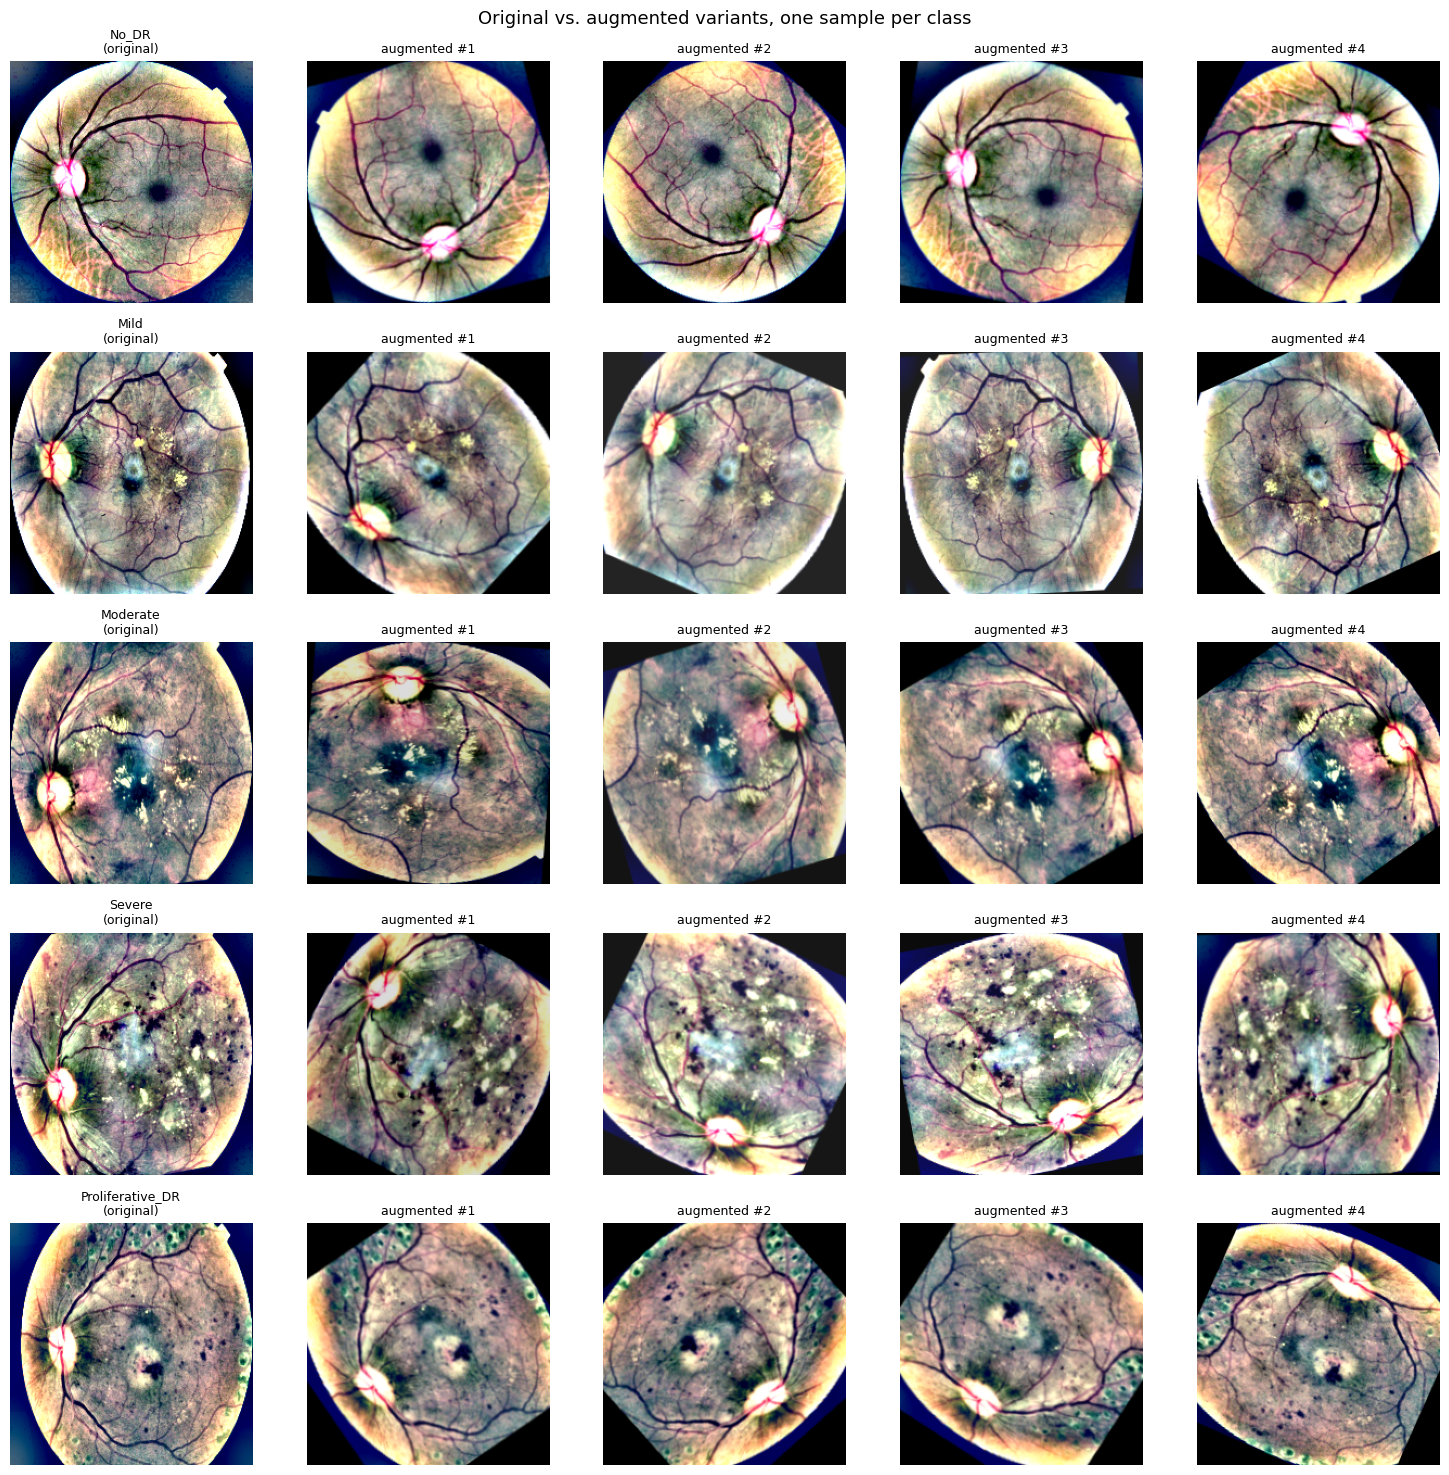

[CELL 9] Saved before/after augmentation visual evidence grid (5 classes x 4 augmented variants each) to /kaggle/working/augmentation_before_after_per_class.png


In [9]:
# [CELL 9] Visual evidence: for one sample image per class, show the original preprocessed image
# next to four independently-sampled augmented variants, so the effect of the Cell 8 pipeline can be
# inspected directly rather than only described.

def load_preprocessed_image_as_rgb(image_id_code, split_directory):
    """Load a saved preprocessed PNG and convert from OpenCV's BGR to RGB for correct matplotlib display."""
    image_path = os.path.join(split_directory, f"{image_id_code}.png")
    bgr_image = cv2.imread(image_path)
    return cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

number_of_augmented_variants_to_show = 4
figure, axes_grid = plt.subplots(
    nrows=5, ncols=1 + number_of_augmented_variants_to_show,
    figsize=(3 * (1 + number_of_augmented_variants_to_show), 15)
)

for row_index, diagnosis_code in enumerate(sorted(diagnosis_code_to_class_name.keys())):
    one_sample_row = train_dataframe[train_dataframe["diagnosis"] == diagnosis_code].iloc[0]
    original_rgb_image = load_preprocessed_image_as_rgb(one_sample_row["id_code"], train_preprocessed_images_directory)

    axes_grid[row_index, 0].imshow(original_rgb_image)
    axes_grid[row_index, 0].set_title(f"{diagnosis_code_to_class_name[diagnosis_code]}\n(original)", fontsize=9)
    axes_grid[row_index, 0].axis("off")

    for variant_index in range(number_of_augmented_variants_to_show):
        augmented_result = augmentation_pipeline(image=original_rgb_image)
        augmented_rgb_image = augmented_result["image"]
        axes_grid[row_index, 1 + variant_index].imshow(augmented_rgb_image)
        axes_grid[row_index, 1 + variant_index].set_title(f"augmented #{variant_index + 1}", fontsize=9)
        axes_grid[row_index, 1 + variant_index].axis("off")

plt.suptitle("Original vs. augmented variants, one sample per class", fontsize=13)
plt.tight_layout()
os.makedirs("/kaggle/working", exist_ok=True)
augmentation_before_after_figure_path = "/kaggle/working/augmentation_before_after_per_class.png"
plt.savefig(augmentation_before_after_figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"[CELL 9] Saved before/after augmentation visual evidence grid (5 classes x "
      f"{number_of_augmented_variants_to_show} augmented variants each) to {augmentation_before_after_figure_path}")


[CELL 10] Target training-split class counts after moderate rebalancing (oversampling capped at 4x per class, never exceeding the majority class count of 1263):
[CELL 10]   No_DR: 1263 real -> 1263 total (0 synthetic augmented images to generate)
[CELL 10]   Mild: 258 real -> 1032 total (774 synthetic augmented images to generate)
[CELL 10]   Moderate: 699 real -> 1263 total (564 synthetic augmented images to generate)
[CELL 10]   Severe: 135 real -> 540 total (405 synthetic augmented images to generate)
[CELL 10]   Proliferative_DR: 207 real -> 828 total (621 synthetic augmented images to generate)
[CELL 10] Imbalance ratio BEFORE rebalancing: 9.36x
[CELL 10] Imbalance ratio AFTER rebalancing:  2.34x
[CELL 10] Total synthetic augmented images to be generated: 2364


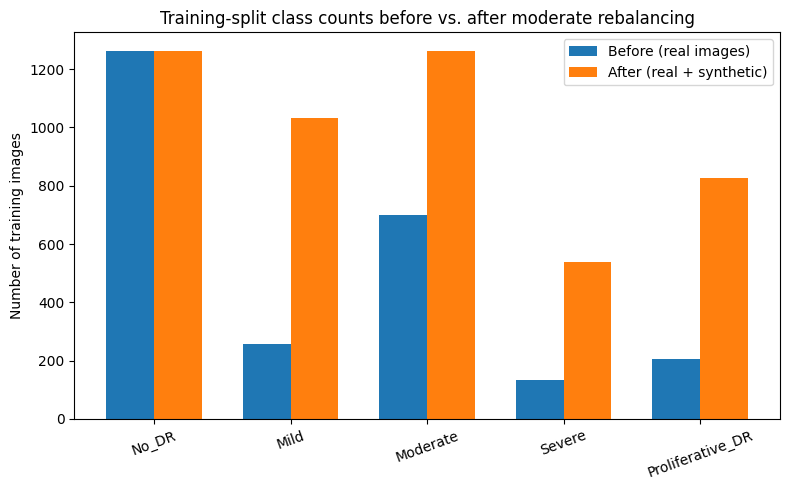

[CELL 10] Saved before/after class-distribution bar chart to /kaggle/working/class_distribution_before_after_rebalancing.png


In [10]:
# [CELL 10] Decide and print the target training-set class counts under the "moderate partial
# rebalance, capped at 4x oversampling per class" strategy agreed above (decision 2 and 3).
#
# HOW THE TARGET IS COMPUTED: for each class, the number of additional (synthetic, augmented) images
# generated is capped so the class's total size never exceeds 4x its original real-image count. This
# is NOT the same as capping at 4x the ORIGINAL SIZE OF EVERY class independently without regard to the
# majority class — the cap below is also never allowed to exceed the majority class's real count, so no
# class is inflated past the size of No_DR, the largest class.

oversampling_multiplier_cap = 4
majority_class_count = training_class_counts_before_augmentation.max()

target_training_class_counts = {}
for diagnosis_code, real_image_count in training_class_counts_before_augmentation.items():
    capped_target = min(real_image_count * oversampling_multiplier_cap, majority_class_count)
    target_training_class_counts[diagnosis_code] = int(capped_target)

print("[CELL 10] Target training-split class counts after moderate rebalancing "
      f"(oversampling capped at {oversampling_multiplier_cap}x per class, never exceeding the "
      f"majority class count of {majority_class_count}):")

total_synthetic_images_to_generate = 0
for diagnosis_code in sorted(target_training_class_counts.keys()):
    real_count = training_class_counts_before_augmentation[diagnosis_code]
    target_count = target_training_class_counts[diagnosis_code]
    synthetic_images_needed = target_count - real_count
    total_synthetic_images_to_generate += synthetic_images_needed
    print(f"[CELL 10]   {diagnosis_code_to_class_name[diagnosis_code]}: {real_count} real -> "
          f"{target_count} total ({synthetic_images_needed} synthetic augmented images to generate)")

new_largest_class_count = max(target_training_class_counts.values())
new_smallest_class_count = min(target_training_class_counts.values())
imbalance_ratio_after_rebalancing = new_largest_class_count / new_smallest_class_count
print(f"[CELL 10] Imbalance ratio BEFORE rebalancing: {training_split_imbalance_ratio:.2f}x")
print(f"[CELL 10] Imbalance ratio AFTER rebalancing:  {imbalance_ratio_after_rebalancing:.2f}x")
print(f"[CELL 10] Total synthetic augmented images to be generated: {total_synthetic_images_to_generate}")

class_count_comparison_figure, comparison_axis = plt.subplots(figsize=(8, 5))
class_names_in_order = [diagnosis_code_to_class_name[code] for code in sorted(target_training_class_counts.keys())]
real_counts_in_order = [training_class_counts_before_augmentation[code] for code in sorted(target_training_class_counts.keys())]
target_counts_in_order = [target_training_class_counts[code] for code in sorted(target_training_class_counts.keys())]

bar_x_positions = np.arange(len(class_names_in_order))
bar_width = 0.35
comparison_axis.bar(bar_x_positions - bar_width / 2, real_counts_in_order, bar_width, label="Before (real images)")
comparison_axis.bar(bar_x_positions + bar_width / 2, target_counts_in_order, bar_width, label="After (real + synthetic)")
comparison_axis.set_xticks(bar_x_positions)
comparison_axis.set_xticklabels(class_names_in_order, rotation=20)
comparison_axis.set_ylabel("Number of training images")
comparison_axis.set_title("Training-split class counts before vs. after moderate rebalancing")
comparison_axis.legend()
plt.tight_layout()
class_distribution_comparison_figure_path = "/kaggle/working/class_distribution_before_after_rebalancing.png"
plt.savefig(class_distribution_comparison_figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"[CELL 10] Saved before/after class-distribution bar chart to {class_distribution_comparison_figure_path}")


In [11]:
# [CELL 11] Generate the synthetic augmented images computed in Cell 10 and save them to disk,
# then build a single manifest CSV listing every training image (real + synthetic) that Notebook 4
# should train on. Validation and test images are copied through UNCHANGED (no augmentation applied),
# since evaluation must always be performed on genuine, real data.

augmented_training_images_directory = "/kaggle/working/augmented_training_images"
os.makedirs(augmented_training_images_directory, exist_ok=True)

training_manifest_rows = []
total_images_written = 0

for diagnosis_code in sorted(target_training_class_counts.keys()):
    class_subset_dataframe = train_dataframe[train_dataframe["diagnosis"] == diagnosis_code].reset_index(drop=True)

    # Every real image for this class is always included as-is (copied, not re-encoded, to avoid
    # any unnecessary lossy re-compression of Notebook 2's already-finished preprocessed output).
    for _row_index, dataset_row in class_subset_dataframe.iterrows():
        source_path = os.path.join(train_preprocessed_images_directory, f"{dataset_row['id_code']}.png")
        destination_path = os.path.join(augmented_training_images_directory, f"{dataset_row['id_code']}.png")
        shutil.copyfile(source_path, destination_path)
        training_manifest_rows.append({
            "id_code": dataset_row["id_code"],
            "diagnosis": diagnosis_code,
            "image_path": destination_path,
            "is_synthetic": False,
        })
        total_images_written += 1

    # Generate the additional synthetic images needed to reach this class's target count, cycling
    # through the class's real source images so every source image contributes roughly equally.
    synthetic_images_needed_for_class = target_training_class_counts[diagnosis_code] - len(class_subset_dataframe)
    for synthetic_image_index in range(synthetic_images_needed_for_class):
        source_row = class_subset_dataframe.iloc[synthetic_image_index % len(class_subset_dataframe)]
        source_rgb_image = load_preprocessed_image_as_rgb(source_row["id_code"], train_preprocessed_images_directory)
        augmented_result = augmentation_pipeline(image=source_rgb_image)
        augmented_rgb_image = augmented_result["image"]
        augmented_bgr_image = cv2.cvtColor(augmented_rgb_image, cv2.COLOR_RGB2BGR)

        synthetic_image_id_code = f"{source_row['id_code']}_aug{synthetic_image_index}"
        destination_path = os.path.join(augmented_training_images_directory, f"{synthetic_image_id_code}.png")
        cv2.imwrite(destination_path, augmented_bgr_image)
        training_manifest_rows.append({
            "id_code": synthetic_image_id_code,
            "diagnosis": diagnosis_code,
            "image_path": destination_path,
            "is_synthetic": True,
        })
        total_images_written += 1

training_manifest_dataframe = pd.DataFrame(training_manifest_rows)
training_manifest_csv_path = "/kaggle/working/training_manifest_augmented.csv"
training_manifest_dataframe.to_csv(training_manifest_csv_path, index=False)

print(f"[CELL 11] Wrote {total_images_written} training images "
      f"({(~training_manifest_dataframe['is_synthetic']).sum()} real + "
      f"{training_manifest_dataframe['is_synthetic'].sum()} synthetic) to {augmented_training_images_directory}")
print(f"[CELL 11] Saved final training manifest CSV to {training_manifest_csv_path}")
print("[CELL 11] Validation and test splits are NOT touched by this cell — Notebook 4 should continue "
      "to load them directly from Notebook 2's original preprocessed_images/validation and /test folders")


[CELL 11] Wrote 4926 training images (2562 real + 2364 synthetic) to /kaggle/working/augmented_training_images
[CELL 11] Saved final training manifest CSV to /kaggle/working/training_manifest_augmented.csv
[CELL 11] Validation and test splits are NOT touched by this cell — Notebook 4 should continue to load them directly from Notebook 2's original preprocessed_images/validation and /test folders


In [12]:
# [CELL 12] Mandatory explicit synthetic-data flag and justification, per the coursework brief's
# requirement that any synthetic/augmented data used in the project must be explicitly stated.

synthetic_image_count = int(training_manifest_dataframe["is_synthetic"].sum())
real_image_count_in_manifest = int((~training_manifest_dataframe["is_synthetic"]).sum())
synthetic_fraction_of_training_set = synthetic_image_count / len(training_manifest_dataframe)

print("[CELL 12] SYNTHETIC DATA DECLARATION")
print(f"[CELL 12] {synthetic_image_count} of {len(training_manifest_dataframe)} training images "
      f"({synthetic_fraction_of_training_set:.1%}) are SYNTHETIC — produced by applying the Cell 8 "
      f"augmentation pipeline (rotation, flip, scale, brightness/contrast) to real source photographs.")
print(f"[CELL 12] {real_image_count_in_manifest} training images are real, unmodified-content "
      f"(preprocessed-only) photographs.")
print("[CELL 12] JUSTIFICATION: synthetic images are used exclusively to correct class imbalance and "
      "increase training diversity, and are confined to the TRAINING split only. The validation and "
      "test splits used for every evaluation metric in later notebooks contain ZERO synthetic images — "
      "so no reported accuracy/precision/recall/F1 figure is inflated by evaluating on synthetic data.")
print("[CELL 12] Oversampling was capped at 4x per class (Cell 10) specifically to limit how much any "
      "single real source image is duplicated-with-variation, reducing (though not eliminating) the "
      "risk that the model memorises augmented variants of a small number of minority-class source "
      "images rather than learning generalisable disease features.")


[CELL 12] SYNTHETIC DATA DECLARATION
[CELL 12] 2364 of 4926 training images (48.0%) are SYNTHETIC — produced by applying the Cell 8 augmentation pipeline (rotation, flip, scale, brightness/contrast) to real source photographs.
[CELL 12] 2562 training images are real, unmodified-content (preprocessed-only) photographs.
[CELL 12] JUSTIFICATION: synthetic images are used exclusively to correct class imbalance and increase training diversity, and are confined to the TRAINING split only. The validation and test splits used for every evaluation metric in later notebooks contain ZERO synthetic images — so no reported accuracy/precision/recall/F1 figure is inflated by evaluating on synthetic data.
[CELL 12] Oversampling was capped at 4x per class (Cell 10) specifically to limit how much any single real source image is duplicated-with-variation, reducing (though not eliminating) the risk that the model memorises augmented variants of a small number of minority-class source images rather than le

In [13]:
# [CELL 13] Compute class weights from the POST-rebalancing training distribution and save them for
# Notebook 4. This is the second half of the "combination" balancing strategy (decision 2 above):
# augmentation has already narrowed the imbalance from 9.35x down to the ratio printed in Cell 10, and
# class weights now absorb whatever imbalance remains, without any further image duplication.

from sklearn.utils.class_weight import compute_class_weight

post_rebalancing_labels_array = training_manifest_dataframe["diagnosis"].values
unique_classes_present = np.array(sorted(target_training_class_counts.keys()))

computed_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes_present,
    y=post_rebalancing_labels_array,
)
class_weights_dictionary = {int(class_code): float(weight) for class_code, weight in zip(unique_classes_present, computed_class_weights)}

print("[CELL 13] Class weights computed from the POST-rebalancing training distribution "
      "(for Notebook 4's loss function, e.g. tf.keras `class_weight=` or a weighted PyTorch loss):")
for diagnosis_code, weight_value in class_weights_dictionary.items():
    print(f"[CELL 13]   {diagnosis_code_to_class_name[diagnosis_code]} (code {diagnosis_code}): weight={weight_value:.4f}")

class_weights_path = "/kaggle/working/class_weights.pkl"
with open(class_weights_path, "wb") as class_weights_file:
    pickle.dump(class_weights_dictionary, class_weights_file)

print(f"[CELL 13] Saved class weights dictionary to {class_weights_path}")


[CELL 13] Class weights computed from the POST-rebalancing training distribution (for Notebook 4's loss function, e.g. tf.keras `class_weight=` or a weighted PyTorch loss):
[CELL 13]   No_DR (code 0): weight=0.7800
[CELL 13]   Mild (code 1): weight=0.9547
[CELL 13]   Moderate (code 2): weight=0.7800
[CELL 13]   Severe (code 3): weight=1.8244
[CELL 13]   Proliferative_DR (code 4): weight=1.1899
[CELL 13] Saved class weights dictionary to /kaggle/working/class_weights.pkl


In [14]:
# [CELL 14] Save the augmentation configuration itself (not just its output images) so the exact
# pipeline used here is fully reproducible and reusable, and print a final summary of every artefact
# this notebook has produced for Notebook 4 to consume.

augmentation_configuration = {
    "random_seed": training_random_seed,
    "rotation_limit_degrees": 180,
    "horizontal_flip_probability": 0.5,
    "vertical_flip_probability": 0.5,
    "random_scale_limit": 0.1,
    "random_scale_probability": 0.7,
    "brightness_contrast_limit": 0.15,
    "brightness_contrast_probability": 0.7,
    "oversampling_multiplier_cap": oversampling_multiplier_cap,
    "target_training_class_counts": target_training_class_counts,
}
augmentation_config_path = "/kaggle/working/augmentation_pipeline_config.pkl"
with open(augmentation_config_path, "wb") as augmentation_config_file:
    pickle.dump(augmentation_configuration, augmentation_config_file)

print(f"[CELL 14] Saved augmentation pipeline configuration to {augmentation_config_path}")
print("[CELL 14] ARTEFACTS PRODUCED BY THIS NOTEBOOK FOR NOTEBOOK 4:")
print(f"[CELL 14]   - {augmented_training_images_directory}/  (final training images: real + synthetic)")
print(f"[CELL 14]   - {training_manifest_csv_path}  (id_code, diagnosis, image_path, is_synthetic per training image)")
print(f"[CELL 14]   - {class_weights_path}  (per-class weight dictionary for the training loss function)")
print(f"[CELL 14]   - {augmentation_config_path}  (exact augmentation parameters used, for reproducibility)")
print(f"[CELL 14]   - Validation split: unchanged, load directly from {validation_preprocessed_images_directory}/ "
      f"and {os.path.join(split_csv_directory, 'validation_split.csv')}")
print(f"[CELL 14]   - Test split: unchanged, load directly from {test_preprocessed_images_directory}/ "
      f"and {os.path.join(split_csv_directory, 'test_split.csv')}")


[CELL 14] Saved augmentation pipeline configuration to /kaggle/working/augmentation_pipeline_config.pkl
[CELL 14] ARTEFACTS PRODUCED BY THIS NOTEBOOK FOR NOTEBOOK 4:
[CELL 14]   - /kaggle/working/augmented_training_images/  (final training images: real + synthetic)
[CELL 14]   - /kaggle/working/training_manifest_augmented.csv  (id_code, diagnosis, image_path, is_synthetic per training image)
[CELL 14]   - /kaggle/working/class_weights.pkl  (per-class weight dictionary for the training loss function)
[CELL 14]   - /kaggle/working/augmentation_pipeline_config.pkl  (exact augmentation parameters used, for reproducibility)
[CELL 14]   - Validation split: unchanged, load directly from /kaggle/input/notebooks/oshadhaksamarasinghe/notebook-2-data-preprocessing/preprocessed_images/validation/ and /kaggle/input/notebooks/oshadhaksamarasinghe/notebook-2-data-preprocessing/validation_split.csv
[CELL 14]   - Test split: unchanged, load directly from /kaggle/input/notebooks/oshadhaksamarasinghe/not

In [15]:
# [CELL 15] Final self-check against Criterion 3 of the marking rubric (10 marks, "Excellent" band
# target), printed explicitly so the report/video can reference exact evidence locations by cell number.

print("[CELL 15] STATUS AGAINST RUBRIC CRITERION 3 (Data Augmentation & Dataset Balancing, 10 marks)")
print("[CELL 15] ------------------------------------------------------------------------------")
print("[CELL 15] Effective, fundus-specific augmentation techniques with strong justification: Cell 8")
print("[CELL 15] Augmentation applied to training split ONLY (val/test untouched): Cells 8, 11, 14")
print("[CELL 15] Visual before/after evidence, per class: Cell 9 "
      "(saved: augmentation_before_after_per_class.png)")
print("[CELL 15] Class imbalance quantified and referenced (9.35x from Notebook 1): Cells 7, 10")
print("[CELL 15] Class imbalance handled appropriately (moderate augmentation + class weights, "
      "justified over full-balance and weights-only alternatives): Cells 10, 11, 13, and intro markdown")
print("[CELL 15] Before/after class counts, quantified and charted: Cell 10 "
      "(saved: class_distribution_before_after_rebalancing.png)")
print("[CELL 15] Synthetic data explicitly flagged and justified: Cell 12")
print(f"[CELL 15] Final training-split imbalance ratio after augmentation: {imbalance_ratio_after_rebalancing:.2f}x "
      f"(down from {training_split_imbalance_ratio:.2f}x); residual imbalance absorbed via class weights (Cell 13)")
print("[CELL 15] Reproducible, saved augmentation pipeline + manifest for Notebook 4: Cell 14")
print("[CELL 15] ------------------------------------------------------------------------------")
print("[CELL 15] Notebook 3 complete.")


[CELL 15] STATUS AGAINST RUBRIC CRITERION 3 (Data Augmentation & Dataset Balancing, 10 marks)
[CELL 15] ------------------------------------------------------------------------------
[CELL 15] Effective, fundus-specific augmentation techniques with strong justification: Cell 8
[CELL 15] Augmentation applied to training split ONLY (val/test untouched): Cells 8, 11, 14
[CELL 15] Visual before/after evidence, per class: Cell 9 (saved: augmentation_before_after_per_class.png)
[CELL 15] Class imbalance quantified and referenced (9.35x from Notebook 1): Cells 7, 10
[CELL 15] Class imbalance handled appropriately (moderate augmentation + class weights, justified over full-balance and weights-only alternatives): Cells 10, 11, 13, and intro markdown
[CELL 15] Before/after class counts, quantified and charted: Cell 10 (saved: class_distribution_before_after_rebalancing.png)
[CELL 15] Synthetic data explicitly flagged and justified: Cell 12
[CELL 15] Final training-split imbalance ratio after aug

---
## Report section (paste-ready draft — Criterion 3)

**What augmentation techniques were applied and why.** Five techniques were used: full-range rotation, horizontal flip, vertical flip, mild random scale (±10%), and mild brightness/contrast adjustment (±15%). Rotation and vertical flip are justified specifically for fundus images because a retinal photograph, captured through a roughly circular aperture, has no canonical "upright" orientation the way a natural photo does — unlike e.g. a chest X-ray, where vertical flipping would invert clinically meaningful anatomy. Horizontal flip mirrors the natural left-eye/right-eye symmetry of fundus photography. Scale and brightness/contrast augmentation were deliberately kept mild: scale, because Notebook 2's dark-border crop already tightly frames the retinal field of view, so an aggressive zoom risks cropping out peripheral retina; brightness/contrast, because Notebook 2's Ben Graham step has already corrected large-scale illumination differences, so an aggressive brightness augmentation would partially undo that correction rather than add useful variety. Elastic distortion and shear were considered and explicitly rejected, since both risk warping fine vessel geometry into anatomically implausible shapes.

**How class imbalance was addressed.** Notebook 1 quantified a 9.35:1 imbalance ratio (No_DR: 1,805 vs. Severe: 193, full dataset). Rather than fully balancing all classes to equality — which would require upsampling Severe by ~9.35x and risk the model memorising near-duplicate augmented copies of a very small number of source images — a moderate, capped strategy was used: oversampling via augmentation was capped at 4x per class, narrowing (not eliminating) the imbalance, and the residual imbalance after capping was handled via class weights (`sklearn.utils.class_weight.compute_class_weight`, `balanced` mode) computed on the post-rebalancing distribution and saved for use in Notebook 4's training loss.

**Quantitative before/after evidence.** [Insert the exact printed numbers from Cell 10's output here once run on Kaggle: real counts, target counts, synthetic images generated per class, and the before/after imbalance ratio.]

**Synthetic data declaration.** [Insert the exact percentage from Cell 12's output here once run.] of the final training set consists of synthetic, augmentation-derived images; augmentation was applied to the training split exclusively, so the validation and test splits used for every evaluation metric in later notebooks contain zero synthetic images.

**Limitations and trade-offs.** Capping oversampling at 4x is a deliberate compromise: it leaves more residual imbalance than full balancing would, relying on class weights to compensate for the remainder — a choice that trades a small amount of unaddressed imbalance for a meaningfully lower risk of minority-class overfitting. The augmentation pipeline's parameters (rotation range, scale range, brightness/contrast range) were fixed globally rather than tuned per class or per image; a class-specific or adaptive augmentation strategy was considered out of scope given the coursework's time constraints.
